In [4]:
import os
import random
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf



In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Mounting files to /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented...
Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [7]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


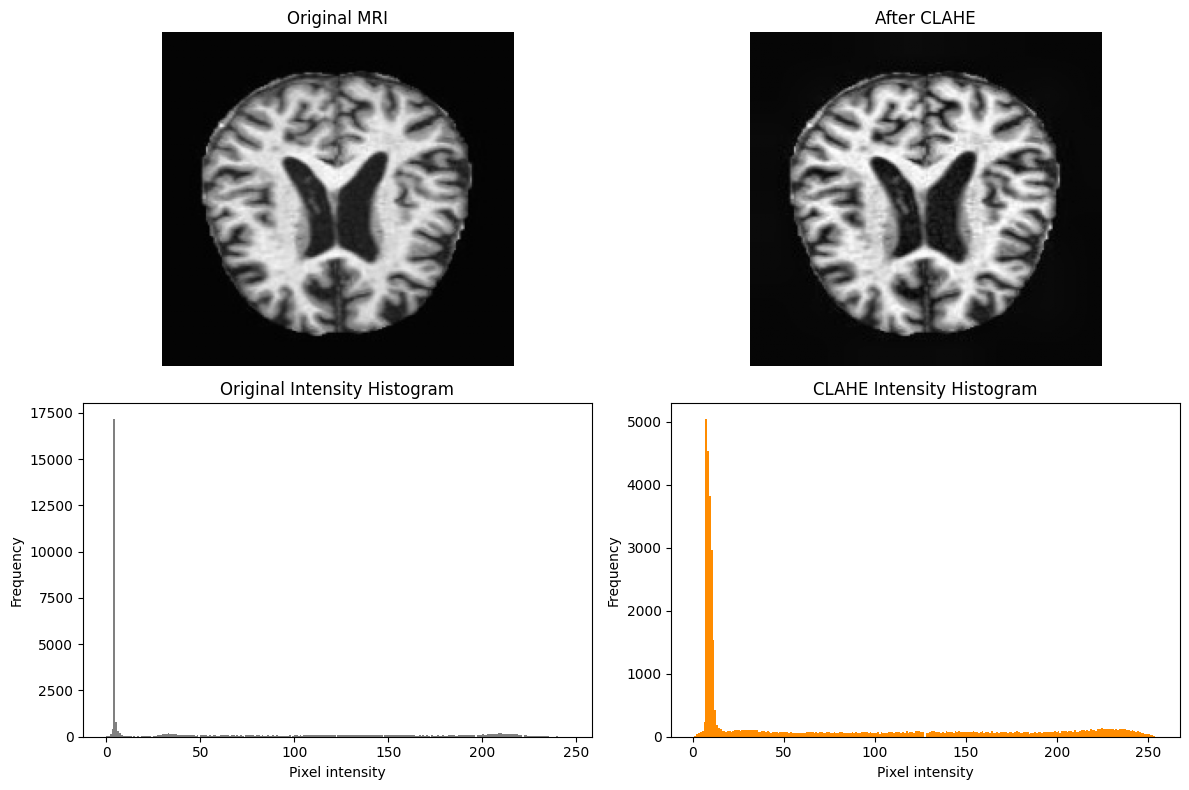

CLAHE clip limit: 2.0
CLAHE tile size: (8, 8)
Original pixel range: 0 to 246
CLAHE pixel range: 1 to 255


In [9]:
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_SIZE
)

sample_path = train_df.sample(
    1,
    random_state=SEED
)["filepath"].iloc[0]

original_image = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

clahe_image = clahe.apply(original_image)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(clahe_image, cmap="gray")
plt.title("After CLAHE")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.hist(original_image.ravel(), bins=256, color="gray")
plt.title("Original Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.hist(clahe_image.ravel(), bins=256, color="darkorange")
plt.title("CLAHE Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("CLAHE clip limit:", CLAHE_CLIP_LIMIT)
print("CLAHE tile size:", CLAHE_TILE_SIZE)
print("Original pixel range:", original_image.min(), "to", original_image.max())
print("CLAHE pixel range:", clahe_image.min(), "to", clahe_image.max())

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def apply_clahe(image):
    image = image.numpy()

    processor = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_SIZE
    )

    return processor.apply(image)


def load_clahe_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=1,
        expand_animations=False
    )
    image.set_shape([None, None, 1])

    image = tf.squeeze(image, axis=-1)

    image = tf.py_function(
        apply_clahe,
        [image],
        Tout=tf.uint8
    )
    image.set_shape([None, None])

    image = tf.image.resize(
        image[..., tf.newaxis],
        IMG_SIZE
    )

    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_clahe_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_clahe_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_clahe_dataset(train_df, training=True)
validation_dataset = create_clahe_dataset(validation_df)
test_dataset = create_clahe_dataset(test_df)

I0000 00:00:1787754345.825217      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 1.0 to 255.0


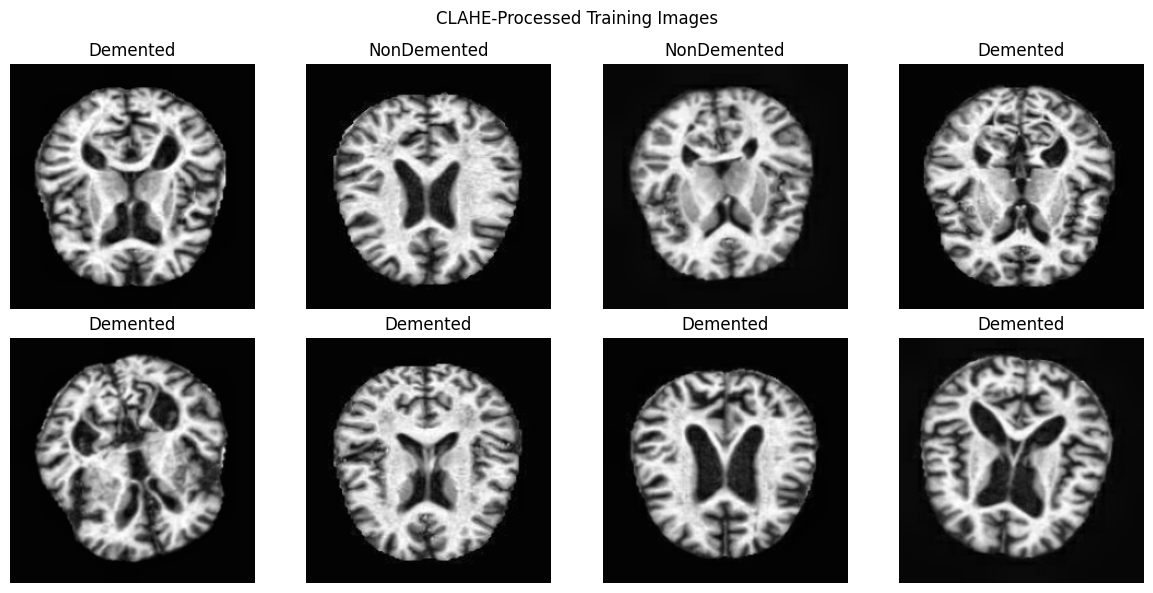

In [11]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())

    plt.figure(figsize=(12, 6))

    for index in range(8):
        plt.subplot(2, 4, index + 1)
        plt.imshow(tf.cast(images[index], tf.uint8))

        class_name = (
            "Demented" if labels[index].numpy() == 1
            else "NonDemented"
        )

        plt.title(class_name)
        plt.axis("off")

    plt.suptitle("CLAHE-Processed Training Images")
    plt.tight_layout()
    plt.show()

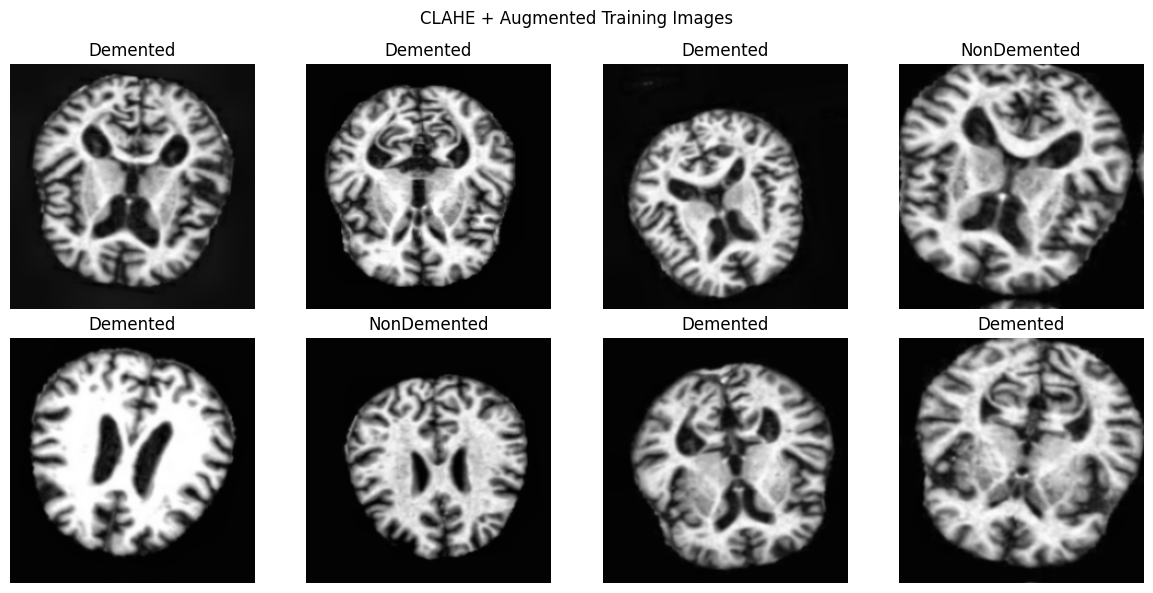

In [12]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            0.05,
            seed=SEED
        ),
        tf.keras.layers.RandomZoom(
            0.10,
            seed=SEED
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED
        )
    ],
    name="data_augmentation"
)

for images, labels in train_dataset.take(1):
    augmented_images = data_augmentation(
        images[:8],
        training=True
    )

    plt.figure(figsize=(12, 6))

    for index in range(8):
        plt.subplot(2, 4, index + 1)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(
                    augmented_images[index],
                    0,
                    255
                ),
                tf.uint8
            )
        )

        class_name = (
            "Demented" if labels[index].numpy() == 1
            else "NonDemented"
        )

        plt.title(class_name)
        plt.axis("off")

    plt.suptitle("CLAHE + Augmented Training Images")
    plt.tight_layout()
    plt.show()

In [13]:
from sklearn.utils.class_weight import compute_class_weight

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Class weights:", class_weights)
print("Preprocessing: CLAHE")
print("CLAHE clip limit:", CLAHE_CLIP_LIMIT)
print("CLAHE tile size:", CLAHE_TILE_SIZE)
print("Data augmentation: Enabled")
print("Rotation: 0.05")
print("Zoom: 0.10")
print("Translation: 0.05")

Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Class weights: {0: 1.71875, 1: 0.7051282051282052}
Preprocessing: CLAHE
CLAHE clip limit: 2.0
CLAHE tile size: (8, 8)
Data augmentation: Enabled
Rotation: 0.05
Zoom: 0.10
Translation: 0.05


In [14]:
resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = resnet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_CLAHE_Aug"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    )
)
print("ResNet50 frozen:", not resnet_base.trainable)
print("CLAHE enabled: True")
print("Augmentation enabled: True")

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
CLAHE enabled: True
Augmentation enabled: True


Model: "ResNet50_CLAHE_Aug"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_clahe_aug_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.6021 - loss: 0.7014
Epoch 1: val_loss improved from None to 0.57984, saving model to /kaggle/working/resnet50_clahe_aug_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_clahe_aug_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 169s 164ms/step - accuracy: 0.6369 - loss: 0.6597 - val_accuracy: 0.6982 - val_loss: 0.5798 - learning_rate: 1.0000e-04
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6882 - loss: 0.5965
Epoch 2: val_loss improved from 0.57984 to 0.53866, saving model to /kaggle/working/resnet50_clahe_aug_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_clahe_aug_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 136s 142ms/step - accuracy: 0.6998 - loss: 0.5825 - val_accuracy: 0.7298 - val_loss: 0.5387 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7119 - loss: 0.5617
Epoch 3: val_loss did not improve from 0.53866
963/

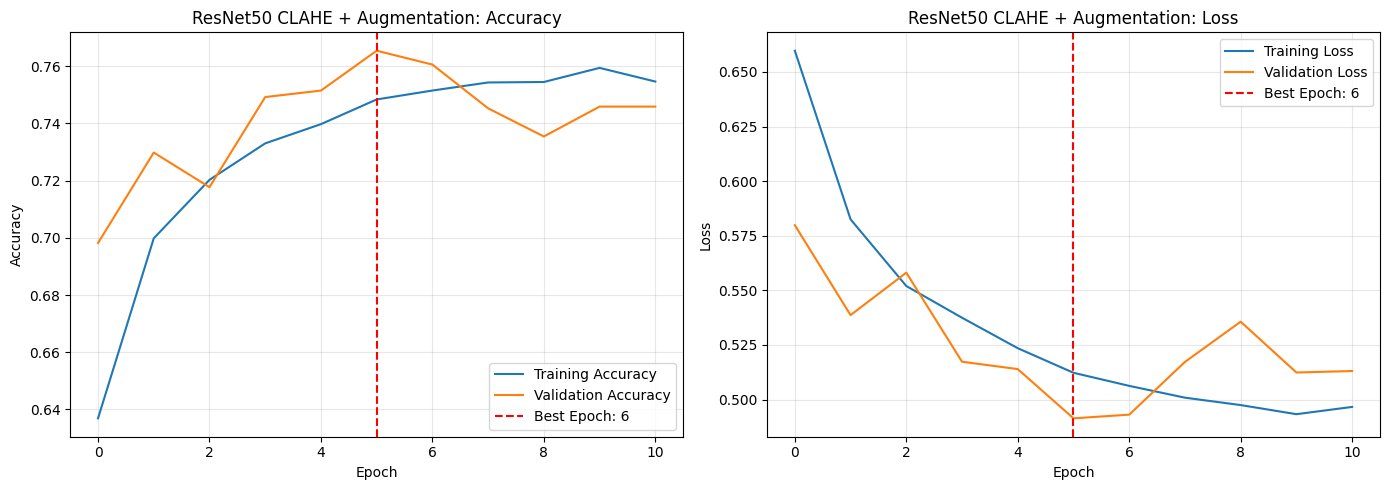

Best epoch: 6


In [16]:
history_df = pd.DataFrame(history.history)

best_epoch = history_df["val_loss"].idxmin() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["accuracy"], label="Training Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title("ResNet50 CLAHE + Augmentation: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["loss"], label="Training Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title("ResNet50 CLAHE + Augmentation: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best epoch:", best_epoch)

In [17]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/resnet50_clahe_aug_best.keras"
)

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 29s 126ms/step - accuracy: 0.7514 - loss: 0.5058
Test Loss: 0.5058
Test Accuracy: 0.7514


In [18]:
test_probabilities = best_model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_df["label"].to_numpy()

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))
print("First probabilities:", test_probabilities[:10].round(4))
print("First predictions:", test_predictions[:10])

207/207 ━━━━━━━━━━━━━━━━━━━━ 27s 120ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
First probabilities: [0.7558 0.4546 0.7974 0.4644 0.5797 0.8238 0.4912 0.2974 0.9126 0.8744]
First predictions: [1 0 1 0 1 1 0 0 1 1]


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(true_labels, test_predictions)
precision = precision_score(true_labels, test_predictions)
recall = recall_score(true_labels, test_predictions)
f1 = f1_score(true_labels, test_predictions)
roc_auc = roc_auc_score(true_labels, test_probabilities)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:\n")
print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

Test Loss: 0.5058
Accuracy: 0.7514
Precision: 0.8968
Recall: 0.7338
F1-score: 0.8071
ROC-AUC: 0.8492

Classification Report:

              precision    recall  f1-score   support

 NonDemented     0.5503    0.7943    0.6502      1920
    Demented     0.8968    0.7338    0.8071      4680

    accuracy                         0.7514      6600
   macro avg     0.7236    0.7640    0.7287      6600
weighted avg     0.7960    0.7514    0.7615      6600



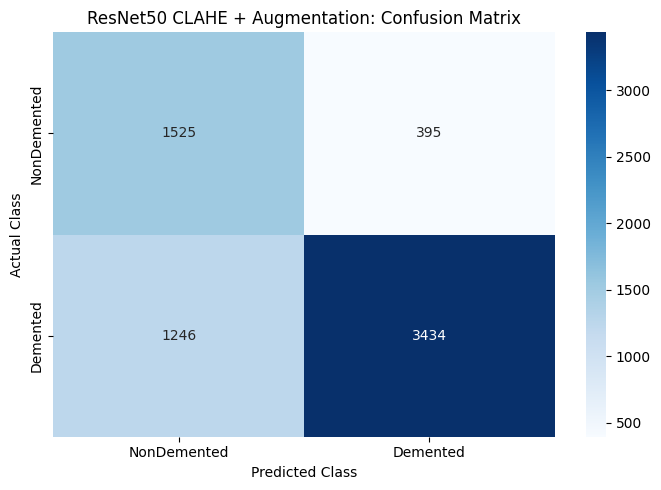

In [20]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 CLAHE + Augmentation: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

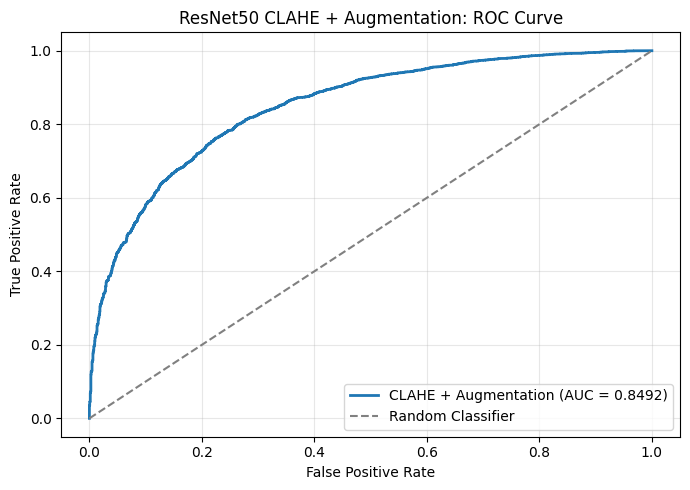

In [21]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    true_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"CLAHE + Augmentation (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ResNet50 CLAHE + Augmentation: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

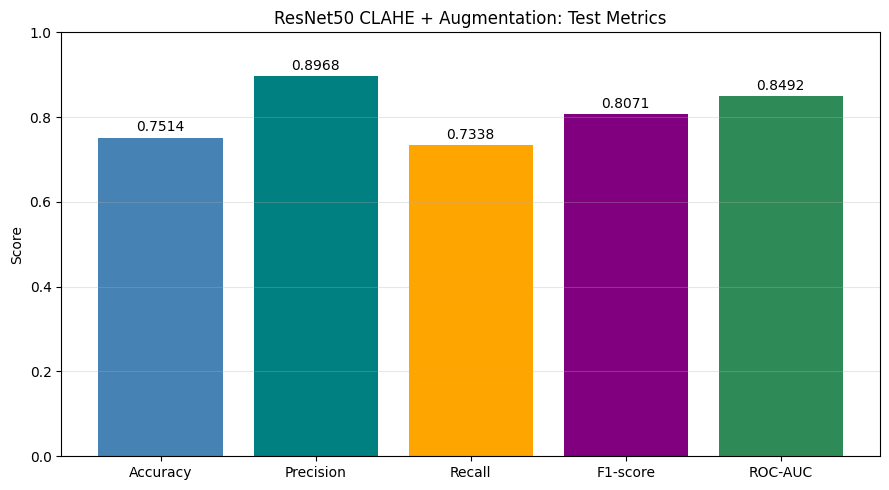

In [22]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metric_names,
    metric_values,
    color=["steelblue", "teal", "orange", "purple", "seagreen"]
)

plt.ylim(0, 1)
plt.title("ResNet50 CLAHE + Augmentation: Test Metrics")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

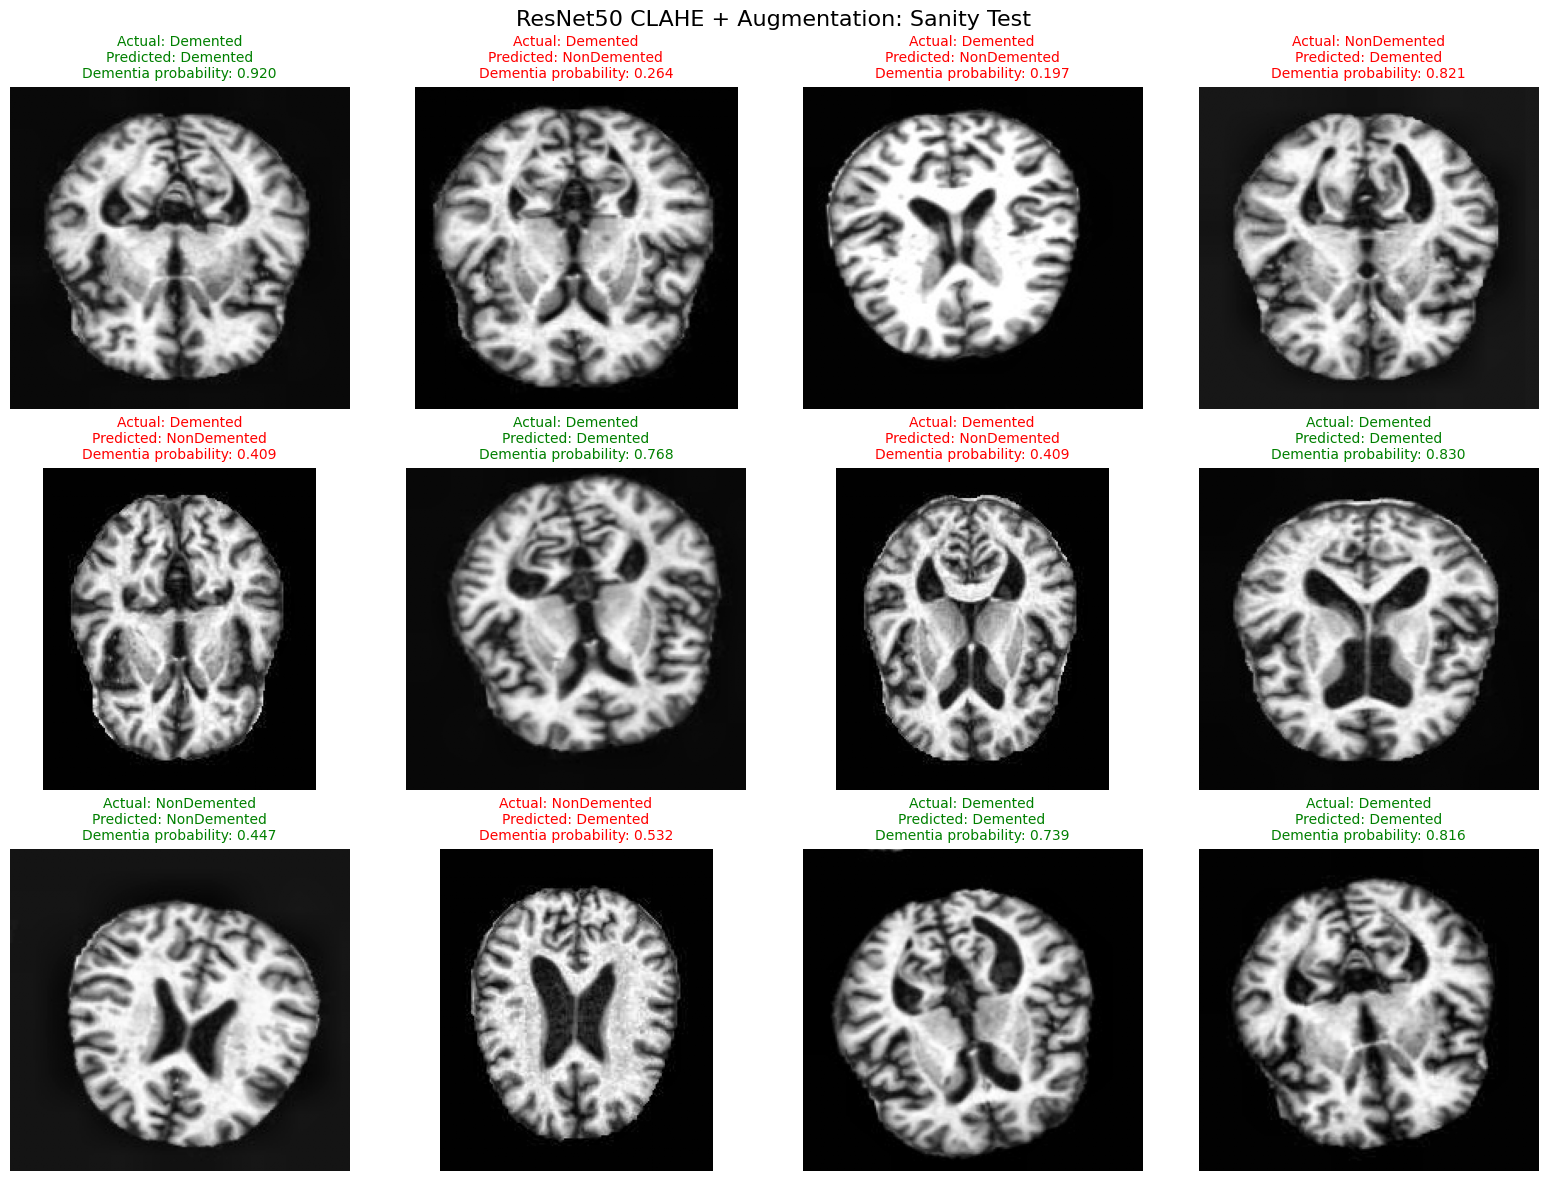

In [23]:
sample_indices = np.random.default_rng(SEED).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(sample_indices, start=1):
    original = cv2.imread(
        test_df.iloc[index]["filepath"],
        cv2.IMREAD_GRAYSCALE
    )

    processor = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_SIZE
    )
    processed = processor.apply(original)

    actual = true_labels[index]
    predicted = test_predictions[index]
    probability = test_probabilities[index]

    actual_name = (
        "Demented" if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented" if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green" if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(processed, cmap="gray")
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Dementia probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle(
    "ResNet50 CLAHE + Augmentation: Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [24]:
results_df = pd.DataFrame([{
    "Experiment": "ResNet50 CLAHE With Augmentation",
    "Model": "ResNet50",
    "Preprocessing": "CLAHE",
    "Augmentation": "Yes",
    "Cross-Validation": "No",
    "CLAHE Clip Limit": CLAHE_CLIP_LIMIT,
    "CLAHE Tile Size": str(CLAHE_TILE_SIZE),
    "Best Epoch": best_epoch,
    "Test Loss": test_loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}])

results_df.to_csv(
    "/kaggle/working/resnet50_clahe_aug_results.csv",
    index=False
)

history_df.to_csv(
    "/kaggle/working/resnet50_clahe_aug_history.csv",
    index=False
)

display(results_df.round(4))

print("Saved:")
print("- resnet50_clahe_aug_best.keras")
print("- resnet50_clahe_aug_results.csv")
print("- resnet50_clahe_aug_history.csv")

,Experiment,Model,Preprocessing,Augmentation,Cross-Validation,CLAHE Clip Limit,CLAHE Tile Size,Best Epoch,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ResNet50 CLAHE With Augmentation,ResNet50,CLAHE,Yes,No,2.0,"(8, 8)",6,0.5058,0.7514,0.8968,0.7338,0.8071,0.8492


Saved:
- resnet50_clahe_aug_best.keras
- resnet50_clahe_aug_results.csv
- resnet50_clahe_aug_history.csv
